In [9]:
# Data manipulation and numerical computation
import numpy as np
import pandas as pd
import os

# pandas all columns display
pd.set_option('display.max_columns', None)

# Load data

In [12]:
# before: path = "../../data/processed/"
path = "data/processed"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)
# keep the odds from the dataframe

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
# df = df.set_index('SamplingOperations_code')


# sort by Date_SamplingOperation
df = df.sort_values(by='Date_SamplingOperation')

# df = df[['CodeSite_SamplingOperations_x', 'Date_SamplingOperation', 'IBD', 'Longitude_Lambert93', 'Latitude_Lambert93']]
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
# df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'Date_SamplingOperation'])

In [13]:
df_copy = df.copy()

end_idx = df.columns.get_loc("Watershed")
new_cols = df.columns[: end_idx + 1]

df = df.loc[:, new_cols].copy()

# add the ibd column
df['IBD'] = df_copy['IBD']
df

SamplingOperations_code CodeSite_SamplingOperations_x  \
2703       S02115200_20070702                     S02115200   
33984      S05218450_20070709                     S05218450   
33929      S05217350_20070709                     S05217350   
48228      S05235850_20070709                     S05235850   
35408      S05234290_20070709                     S05234290   
...                       ...                           ...   
42720      S06580577_20230907                     S06580577   
35760      S06001284_20230907                     S06001284   
35783      S06001533_20230907                     S06001533   
38878      S06137040_20231011                     S06137040   
38873      S06137014_20231011                     S06137014   

      Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
2703              2007-07-02                               400      NaN   
33984             2007-07-09                               400      NaN   
33929             2007-07-09                               400      NaN   
48228             2007-07-09                               400      NaN   
35408             2007-07-09                               400      NaN   
...                      ...                               ...      ...   
42720             2023-09-07                               426      NaN   
35760             2023-09-07                               421      NaN   
35783             2023-09-07                               401      NaN   
38878             2023-10-11                               400      NaN   
38873             2023-10-11                               405      NaN   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      2.5      NaN      NaN      NaN      NaN      NaN   
35408      NaN      7.5      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

         Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
2703         NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929   5.000000      NaN      NaN      NaN      NaN      NaN      NaN   
48228  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
35408  20.000000      NaN      NaN      NaN      NaN      NaN      NaN   
...          ...      ...      ...      ...      ...      ...      ...   
42720   4.694836      NaN      NaN      NaN      NaN      NaN      NaN   
35760        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783  14.962594      NaN      NaN      NaN      NaN      NaN      NaN   
38878  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
38873  69.135802      NaN      NaN      NaN      NaN      NaN      NaN   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
2703       NaN      NaN      NaN      NaN      NaN      NaN     12.5      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN    

In [14]:
df = df.drop(columns=['CodeSite_SamplingOperations_x', 'Watershed'])

In [15]:
# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

In [16]:
# keep the columns with less than 99% NaN 
df = df.loc[:, df.isnull().mean() < 0.99]

In [17]:
# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

In [18]:
# display some rows
pd.set_option("display.max_columns", 8)

df

,SamplingOperations_code,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaf02,...,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,IBD
2703,S02115200_20070702,2007-07-02,400,NaN,...,NaN,902925.0,6941112.0,10.5
33984,S05218450_20070709,2007-07-09,400,NaN,...,NaN,442885.0,6199880.0,20.0
33929,S05217350_20070709,2007-07-09,400,NaN,...,NaN,442250.0,6218040.0,20.0
48228,S05235850_20070709,2007-07-09,400,NaN,...,2.500000,463192.0,6225280.0,NaN
35408,S05234290_20070709,2007-07-09,400,NaN,...,10.000000,456573.0,6224410.0,16.6
...,...,...,...,...,...,...,...,...,...
42720,S06580577_20230907,2023-09-07,426,NaN,...,4.694836,908596.0,6499943.0,14.5
35760,S06001284_20230907,2023-09-07,421,NaN,...,87.885986,910629.0,6500149.0,16.3
35783,S06001533_20230907,2023-09-07,401,NaN,...,62.344140,909322.0,6499820.0,14.8
38878,S06137040_20231011,2023-10-11,400,NaN,...,10.000000,967828.0,6518569.0,20.0


In [ ]:
# =========================================================
# IBD prediction from sparse taxa + spatiotemporal features
# Requires: pandas, numpy, scipy, scikit-learn
# Input:  df (wide), columns include:
#   ['SamplingOperations_code','Date_SamplingOperation','TotalAbundance_SamplingOperation',
#    many taxa columns ..., 'Longitude_Lambert93','Latitude_Lambert93','IBD']
# =========================================================

import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import warnings

# -----------------------------
# 1) Identify columns
# -----------------------------
def infer_taxa_columns(df: pd.DataFrame):
    base_cols = {
        'SamplingOperations_code',
        'Date_SamplingOperation',
        'TotalAbundance_SamplingOperation',
        'Longitude_Lambert93',
        'Latitude_Lambert93',
        'IBD',
    }
    taxa_cols = [c for c in df.columns if c not in base_cols]
    # keep only numeric taxa cols
    taxa_cols = [c for c in taxa_cols if pd.api.types.is_numeric_dtype(df[c])]
    return taxa_cols

# -----------------------------
# 2) Site/date/coords features
# -----------------------------
def add_keys_and_time(df: pd.DataFrame):
    out = df.copy()
    # Site code before last '_' (format: SITE_YYYYMMDD)
    out['CodeSite'] = out['SamplingOperations_code'].astype(str).str.rsplit('_', n=1).str[0]
    # Parse date
    out['Date_SamplingOperation'] = pd.to_datetime(out['Date_SamplingOperation'], errors='coerce')
    # Day-of-year cyclical
    doy = out['Date_SamplingOperation'].dt.dayofyear.astype('float64')
    out['sin_doy'] = np.sin(2*np.pi*(doy/365.25))
    out['cos_doy'] = np.cos(2*np.pi*(doy/365.25))
    # Year (centered)
    yr = out['Date_SamplingOperation'].dt.year.astype('float64')
    yr_mean = np.nanmean(yr)
    out['year_c'] = (yr - yr_mean)
    # Lambert93 in km for scale
    out['x_km'] = out['Longitude_Lambert93'] / 1000.0
    out['y_km'] = out['Latitude_Lambert93']  / 1000.0
    # Simple coord impute (median)
    for c in ['x_km','y_km','sin_doy','cos_doy','year_c']:
        if out[c].isna().any():
            out[c] = out[c].fillna(out[c].median())
    return out

# -----------------------------
# 3) Detect taxa scale (counts vs %)
# -----------------------------
def detect_scale(taxa_df: pd.DataFrame, total_col: pd.Series):
    # Robust check on a subsample to avoid huge sums
    sub = taxa_df.sample(min(5000, len(taxa_df)), random_state=123) if len(taxa_df) > 5000 else taxa_df
    sums = sub.fillna(0).sum(axis=1)
    tot  = total_col.loc[sub.index].fillna(sub.get('TotalAbundance_SamplingOperation', pd.Series(index=sub.index, dtype=float))).fillna(400)
    ratio = np.median((sums + 1e-9) / (tot + 1e-9))
    # Heuristics:
    # ~1.0 => counts; ~100 => percentages; ~1/100 => proportions in [0,1]
    if 0.5 <= ratio <= 2.0:
        return 'counts'
    if 50 <= ratio <= 200:
        return 'percent'
    if 0.005 <= ratio <= 0.02:
        return 'proportion'
    # default
    return 'counts'

def to_counts_matrix(taxa_df: pd.DataFrame, total_col: pd.Series, scale_hint: str):
    X = taxa_df.copy()
    X = X.fillna(0.0)
    if scale_hint == 'counts':
        counts = X.values
    elif scale_hint == 'percent':
        # convert % to counts using total
        tot = total_col.fillna(400).to_numpy(dtype=float).reshape(-1,1)
        counts = (X.values/100.0) * tot
    elif scale_hint == 'proportion':
        tot = total_col.fillna(400).to_numpy(dtype=float).reshape(-1,1)
        counts = X.values * tot
    else:
        counts = X.values
    # log1p counts is stable for sparsity
    X_taxa_log1p = np.log1p(counts, dtype=float)
    # convert to CSR
    X_taxa_csr = sp.csr_matrix(X_taxa_log1p)
    return X_taxa_csr

# -----------------------------
# 4) Build st features matrix
# -----------------------------
def make_spatiotemporal_matrix(df_feat: pd.DataFrame):
    Z = df_feat[['x_km','y_km','sin_doy','cos_doy','year_c']].to_numpy(dtype=float)
    # scale small dense features
    scaler = StandardScaler(with_mean=True, with_std=True)
    Zs = scaler.fit_transform(Z)
    return sp.csr_matrix(Zs), scaler

# -----------------------------
# 5) Grouped CV + training
# -----------------------------
def train_elasticnet_groupcv(X_taxa, X_st, y, groups, n_splits=5, random_state=123):
    X = sp.hstack([X_taxa, X_st], format='csr')
    gkf = GroupKFold(n_splits=n_splits)
    y = y.astype(float)

    oof_pred = np.full_like(y, fill_value=np.nan, dtype=float)
    models = []
    for tr, te in gkf.split(X, y, groups):
        # inner ElasticNetCV for alpha/l1_ratio
        enetcv = ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-4, 1, 30),
            max_iter=20000,
            cv=3,
            n_jobs=-1,
            random_state=random_state,
        )
        enetcv.fit(X[tr], y[tr])
        pred = enetcv.predict(X[te])
        oof_pred[te] = pred
        # refit a plain ElasticNet at best hyperparams for compactness
        m = ElasticNet(alpha=enetcv.alpha_, l1_ratio=enetcv.l1_ratio_,
                       max_iter=20000, random_state=random_state)
        m.fit(X[tr], y[tr])
        models.append(m)

    # Metrics on OOF
    mae = mean_absolute_error(y[~np.isnan(oof_pred)], oof_pred[~np.isnan(oof_pred)])
    rmse = np.sqrt(mean_squared_error(y[~np.isnan(oof_pred)], oof_pred[~np.isnan(oof_pred)]))
    r2 = r2_score(y[~np.isnan(oof_pred)], oof_pred[~np.isnan(oof_pred)])

    # Final refit on all data with the median hyperparams across folds
    alphas  = [m.alpha for m in models]
    l1s     = [m.l1_ratio for m in models]
    alpha_f = float(np.median(alphas))
    l1_f    = float(np.median(l1s))
    final = ElasticNet(alpha=alpha_f, l1_ratio=l1_f, max_iter=20000, random_state=random_state)
    final.fit(X, y)

    return {
        'X': X, 'models': models, 'final': final,
        'oof_pred': oof_pred,
        'metrics': {'MAE': mae, 'RMSE': rmse, 'R2': r2},
        'alpha_final': alpha_f, 'l1_final': l1_f,
    }

# -----------------------------
# 6) Conformal intervals (simple absolute residual)
# -----------------------------
def conformal_interval(oof_pred, y, alpha=0.10):
    # 90% PI by quantile of absolute OOF residuals
    resid = np.abs(y - oof_pred)
    resid = resid[~np.isnan(resid)]
    q = np.quantile(resid, 1 - alpha)
    return float(q)

# -----------------------------
# 7) Coeff inspection
# -----------------------------
def top_taxa_coefficients(model: ElasticNet, taxa_cols, st_dim):
    coef = model.coef_.ravel()
    taxa_coef = coef[:len(taxa_cols)]
    st_coef   = coef[len(taxa_cols):len(taxa_cols)+st_dim]
    # top positive and negative taxa
    k = min(30, len(taxa_cols))
    top_pos_idx = np.argsort(-taxa_coef)[:k]
    top_neg_idx = np.argsort(taxa_coef)[:k]
    top_pos = pd.DataFrame({
        'feature': np.array(taxa_cols)[top_pos_idx],
        'coef': taxa_coef[top_pos_idx]
    })
    top_neg = pd.DataFrame({
        'feature': np.array(taxa_cols)[top_neg_idx],
        'coef': taxa_coef[top_neg_idx]
    })
    st_names = ['x_km','y_km','sin_doy','cos_doy','year_c']
    st_df = pd.DataFrame({'feature': st_names[:st_dim], 'coef': st_coef[:st_dim]})
    return top_pos, top_neg, st_df

# -----------------------------
# 8) Orchestrator
# -----------------------------
def fit_predict_ibd(df: pd.DataFrame, seed=123):
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)

    taxa_cols = infer_taxa_columns(df)
    df2 = add_keys_and_time(df)

    # Train indices (rows with IBD available)
    mask_train = df2['IBD'].notna()
    mask_infer = ~mask_train

    taxa_df = df2.loc[:, taxa_cols]
    scale_hint = detect_scale(taxa_df, df2['TotalAbundance_SamplingOperation'])
    X_taxa = to_counts_matrix(taxa_df, df2['TotalAbundance_SamplingOperation'], scale_hint)

    X_st, st_scaler = make_spatiotemporal_matrix(df2)
    st_dim = X_st.shape[1]

    # Train on available IBD
    y_train = df2.loc[mask_train, 'IBD'].to_numpy(dtype=float)
    groups  = df2.loc[mask_train, 'CodeSite'].astype(str).to_numpy()

    X_taxa_tr = X_taxa[mask_train.values]
    X_st_tr   = X_st[mask_train.values]

    res = train_elasticnet_groupcv(X_taxa_tr, X_st_tr, y_train, groups, n_splits=5, random_state=seed)

    # Conformal radius from OOF
    q90 = conformal_interval(res['oof_pred'], y_train, alpha=0.10)

    # Final predictions for all rows (including missing IBD)
    X_all = sp.hstack([X_taxa, X_st], format='csr')
    y_hat_all = res['final'].predict(X_all)

    # Package outputs
    out = df2[['SamplingOperations_code','CodeSite','Date_SamplingOperation','Longitude_Lambert93','Latitude_Lambert93','IBD']].copy()
    out['IBD_pred'] = y_hat_all
    out['PI90_lo']  = out['IBD_pred'] - q90
    out['PI90_hi']  = out['IBD_pred'] + q90
    out['was_missing'] = out['IBD'].isna()

    # Top coefficients
    top_pos, top_neg, st_df = top_taxa_coefficients(res['final'], taxa_cols, st_dim)

    report = {
        'cv_metrics': res['metrics'],
        'alpha_final': res['alpha_final'],
        'l1_final': res['l1_final'],
        'scale_hint': scale_hint,
        'conformal_q90': q90
    }

    return out, report, top_pos, top_neg, st_df

# -----------------------------
# 9) Example usage
# -----------------------------


In [20]:
out_df, report, top_pos, top_neg, st_feats = fit_predict_ibd(df)

In [29]:
# df where IBD is missing
df_pred = df.copy()
df_pred = df_pred[df_pred['IBD'].isna()]
df_pred = df_pred.set_index('SamplingOperations_code')
df_pred

,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaf02,Achat02,...,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,IBD
SamplingOperations_code,,,,,,,,,
S05235850_20070709,2007-07-09,400,NaN,42.500000,...,2.500000,463192.0,6225280.0,NaN
S05113000_20070723,2007-07-23,433,NaN,NaN,...,2.309469,509659.0,6343380.0,NaN
S05082000_20070724,2007-07-24,400,NaN,NaN,...,37.500000,471406.0,6378420.0,NaN
S05111500_20070724,2007-07-24,414,NaN,2.415459,...,2.415459,491863.0,6353390.0,NaN
S05086000_20070725,2007-07-25,424,NaN,NaN,...,14.150943,510596.0,6374210.0,NaN
...,...,...,...,...,...,...,...,...,...
S06173650_20230720,2023-07-20,416,NaN,NaN,...,14.423077,677096.0,6188782.0,NaN
S06076420_20230726,2023-07-26,399,NaN,NaN,...,22.556391,906897.0,6538264.0,NaN
S06830139_20230818,2023-08-18,394,NaN,NaN,...,73.604061,945699.0,6512670.0,NaN


In [ ]:
pred = out_df[['IBD_pred', 'SamplingOperations_code']]
pred = pred.set_index('SamplingOperations_code')
pred_missing = pred.loc[df_pred.index]
pred_missing = pred_missing.merge(
    df_copy[['SamplingOperations_code','HERlvl1Name']].set_index('SamplingOperations_code'), left_index=True, right_index=True, how='left'
)

In [91]:
from scripts import mapping as mp

# after saving scripts/mapping.py
import importlib
importlib.reload(mp)        # mp came from: from scripts import mapping as mp

<module 'scripts.mapping' from 'c:\\Users\\herie\\OneDrive - Fundacion Universidad de las Americas Puebla\\Proyectos\\En Proceso\\Clasificacion-de-Calidad-del-Agua-IBD-EQR\\scripts\\mapping.py'>

In [92]:
ranges = mp.get_ranges(tol=1)

In [90]:
mp.get_results(
    pred_missing,
    ranges,
    pred_col="IBD_pred",
    output_file="results/008_Elastic_Net/ElasticNet.csv",
    index=True,
)

Saved predictions to results/008_Elastic_Net/ElasticNet.csv


,IBD_EQR_Status
SamplingOperations_code,
S05235850_20070709,High
S05113000_20070723,Poor
S05082000_20070724,Poor
S05111500_20070724,Bad
S05086000_20070725,Moderate
...,...
S06173650_20230720,Moderate
S06076420_20230726,Good
S06830139_20230818,High


In [57]:
ranges

,HERlvl1Name,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
0,ALPES INTERNES,Bad,0.000,9.800,9.30
1,ALPES INTERNES,Poor,9.800,13.225,10.30
2,ALPES INTERNES,Moderate,13.225,17.025,16.15
3,ALPES INTERNES,Good,17.025,18.725,17.90
4,ALPES INTERNES,High,18.725,20.000,19.55
...,...,...,...,...,...
105,VOSGES,Bad,0.000,9.550,7.90
106,VOSGES,Poor,9.550,12.775,11.20
107,VOSGES,Moderate,12.775,15.700,14.35
108,VOSGES,Good,15.700,18.075,17.05


In [21]:
report

{'cv_metrics': {'MAE': 0.863236368264281,
  'RMSE': np.float64(1.1851799008126138),
  'R2': 0.819938484116862},
 'alpha_final': 0.007880462815669913,
 'l1_final': 0.1,
 'scale_hint': 'counts',
 'conformal_q90': 1.809349719434689}

In [22]:
out_df[out_df['was_missing']].head()

,SamplingOperations_code,CodeSite,Date_SamplingOperation,Longitude_Lambert93,...,IBD_pred,PI90_lo,PI90_hi,was_missing
48228,S05235850_20070709,S05235850,2007-07-09,463192.0,...,20.442998,18.633649,22.252348,True
47256,S05113000_20070723,S05113000,2007-07-23,509659.0,...,10.455086,8.645737,12.264436,True
47024,S05082000_20070724,S05082000,2007-07-24,471406.0,...,13.562774,11.753424,15.372124,True
47237,S05111500_20070724,S05111500,2007-07-24,491863.0,...,9.655427,7.846077,11.464776,True
47042,S05086000_20070725,S05086000,2007-07-25,510596.0,...,16.252298,14.442949,18.061648,True


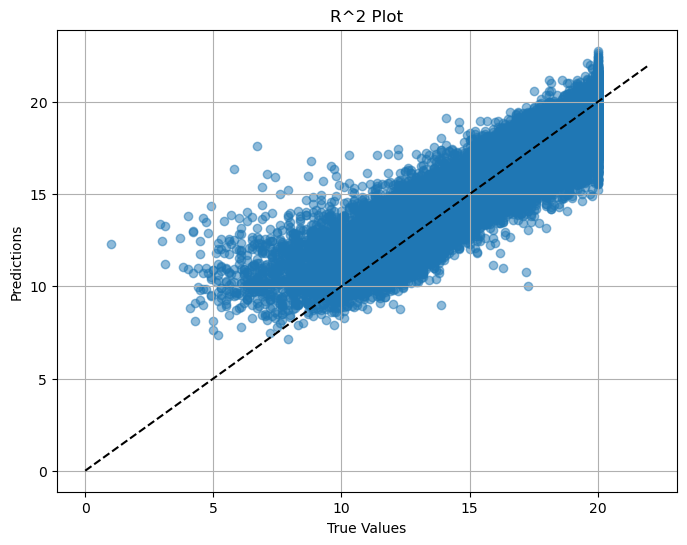

In [98]:
# plot the r^2
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot([0, 22], [0, 22], 'k--')
plt.scatter(out_df['IBD'], out_df['IBD_pred'], alpha=0.5)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('R^2 Plot')
plt.grid()
plt.show()


In [26]:
out_df

,SamplingOperations_code,CodeSite,Date_SamplingOperation,Longitude_Lambert93,...,IBD_pred,PI90_lo,PI90_hi,was_missing
2703,S02115200_20070702,S02115200,2007-07-02,902925.0,...,10.125229,8.315879,11.934579,False
33984,S05218450_20070709,S05218450,2007-07-09,442885.0,...,20.424919,18.615569,22.234268,False
33929,S05217350_20070709,S05217350,2007-07-09,442250.0,...,19.775035,17.965685,21.584385,False
48228,S05235850_20070709,S05235850,2007-07-09,463192.0,...,20.442998,18.633649,22.252348,True
35408,S05234290_20070709,S05234290,2007-07-09,456573.0,...,16.431356,14.622007,18.240706,False
...,...,...,...,...,...,...,...,...,...
42720,S06580577_20230907,S06580577,2023-09-07,908596.0,...,14.439386,12.630037,16.248736,False
35760,S06001284_20230907,S06001284,2023-09-07,910629.0,...,16.224396,14.415046,18.033746,False
35783,S06001533_20230907,S06001533,2023-09-07,909322.0,...,15.867171,14.057821,17.676521,False
38878,S06137040_20231011,S06137040,2023-10-11,967828.0,...,18.763642,16.954293,20.572992,False


In [23]:
top_pos

,feature,coef
0,Achpy01,0.375524
1,Achmi02,0.287785
2,Achob01,0.277401
3,Himex01,0.264361
4,Plaob01,0.249394
5,Achri01,0.201730
6,Psaob01,0.191054
7,Eunim01,0.164046
8,Achmi03,0.162131
9,Achsu03,0.155754


In [24]:
top_neg

,feature,coef
0,Navsa03,-0.311785
1,Navmu06,-0.284481
2,Nitfr02,-0.230184
3,Diaco01,-0.216051
4,Cymaf01,-0.215083
5,Selsa02,-0.198393
6,Navsu09,-0.194705
7,Selni01,-0.183196
8,Bacpa01,-0.174817
9,Crasu01,-0.160412


In [25]:
st_feats

,feature,coef
0,x_km,-0.042810
1,y_km,0.000026
2,sin_doy,0.022139
3,cos_doy,0.020773
4,year_c,-0.057008
